In [1]:
!unset LD_LIBRARY_PATH

In [2]:
# %load_ext autoreload
# %autoreload 2

import os

from functools import partial

if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = "jax"

import blackjax
import bayesflow as bf
import jax
import jax.numpy as jnp
import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from mcmc import model_nle, warmup
from plots import create_profile_likelihood_plot
from priors import truncated_normal_rvs
from rdmc import rdmc_experiment_simple

INFO:2025-10-10 17:52:09,158:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


In [3]:
def prior_fun_train(
    drift_c_intercept_loc=0.05,
    drift_c_intercept_scale=0.05,
    drift_c_slope_loc=0.5,
    drift_c_slope_scale=0.1,
    amp_shape=10,
    amp_scale=2,
    tau_shape=8,
    tau_scale=10,
    sd_true_shape=80,
    sd_true_scale=0.05,
    threshold_shape=100,
    threshold_scale=0.7,
    t0_loc=300,
    t0_scale=50,
    rng=np.random.default_rng(2025),
):
    drift_c_intercept = truncated_normal_rvs(drift_c_intercept_loc, drift_c_intercept_scale, random_state=rng)
    drift_c_slope = truncated_normal_rvs(drift_c_slope_loc, drift_c_slope_scale, random_state=rng)
    amp = rng.gamma(shape=amp_shape, scale=amp_scale)
    tau = rng.gamma(shape=tau_shape, scale=tau_scale)
    s_true = rng.gamma(shape=sd_true_shape, scale=sd_true_scale)
    b = rng.gamma(shape=threshold_shape, scale=threshold_scale)
    t0 = truncated_normal_rvs(t0_loc, t0_scale, random_state=rng)

    return {
        "v_c_intercept": drift_c_intercept,
        "v_c_slope": drift_c_slope,
        "amp": amp,
        "tau": tau,
        "s_true": s_true,
        "b": b,
        "t0": t0
    }

In [4]:
def simulator_fun(**kwargs):
    return rdmc_experiment_simple(**kwargs, t_max=2000, seed=2025, a_shape=2, s_false=4)


def meta(batch_size):
    num_obs = np.random.default_rng(2025).integers(250, 500)

    return dict(num_obs=num_obs)

simulator = bf.simulators.make_simulator([prior_fun_train, simulator_fun], meta_fn=meta)

In [5]:
param_names = ["v_c_intercept", "v_c_slope", "tau", "amp", "s_true", "b", "t0"]

In [6]:
approximator = keras.saving.load_model("rdmc_nle.keras")

In [7]:
test_data = simulator.sample(1)
prior_draws = np.array([test_data[p] for p in param_names]).squeeze()
approximator.log_prob(test_data).sum()

-170.45439

In [8]:
model_nle(test_data, approximator)(prior_draws)

Array(-170.45425, dtype=float32)

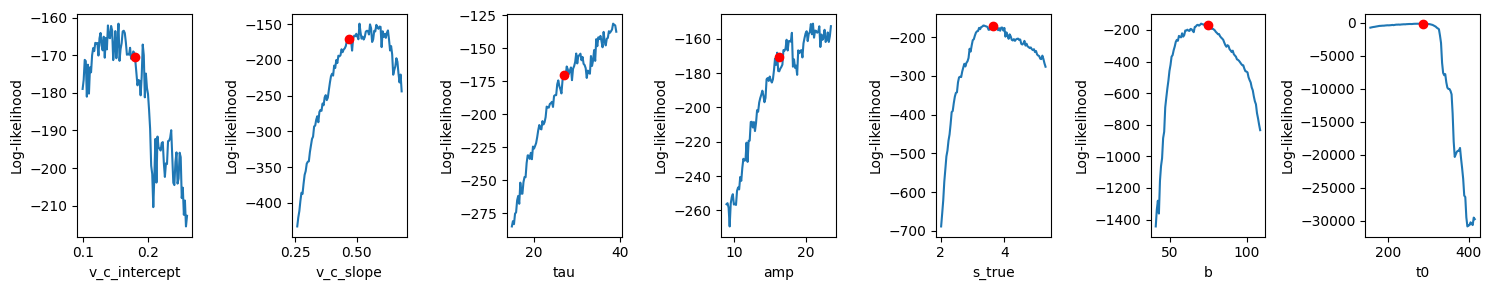

In [9]:
_ = create_profile_likelihood_plot(model_nle, test_data, approximator, prior_draws, param_names)

In [10]:
rng_key = jax.random.key(2025)

In [11]:
# inv_mass_matrix = jnp.eye(len(param_names)) * 1e-4  # 5x5 for five parameters
inv_mass_matrix = jnp.array([7.73e-05, 4.44e-04, 2.36e+02, 2.42e+01,
        2.25e-01, 2.06e+01, 5.65e+00])
n_samples = 1000

In [12]:
import blackjax.smc.resampling as resampling
from blackjax.smc import extend_params

def smc_inference_loop(rng_key, smc_kernel, initial_state):
    """Run the temepered SMC algorithm.

    We run the adaptive algorithm until the tempering parameter lambda reaches the value
    lambda=1.

    """

    def cond(carry):
        i, state, _k = carry
        return state.lmbda < 1

    @jax.jit
    def one_step(carry):
        i, state, k = carry
        k, subk = jax.random.split(k, 2)
        state, _ = smc_kernel(subk, state)
        return i + 1, state, k

    n_iter, final_state, _ = jax.lax.while_loop(
        cond, one_step, (0, initial_state, rng_key)
    )

    return n_iter, final_state

In [13]:
def prior_log_prob(x):
    # x shape: (..., 7)
    v_c_intercept_lp = jax.scipy.stats.norm.logpdf(x[..., 0], loc=0.05, scale=0.05)
    v_c_slope_lp     = jax.scipy.stats.norm.logpdf(x[..., 1], loc=0.5, scale=0.1)
    tau_lp           = jax.scipy.stats.gamma.logpdf(x[..., 2], a=8, scale=10)
    amp_lp           = jax.scipy.stats.gamma.logpdf(x[..., 3], a=10, scale=2)
    s_true_lp        = jax.scipy.stats.gamma.logpdf(x[..., 4], a=80, scale=0.05)
    b_lp             = jax.scipy.stats.gamma.logpdf(x[..., 5], a=100, scale=0.7)
    t0_lp            = jax.scipy.stats.norm.logpdf(x[..., 6], loc=300, scale=50)
    return (
        v_c_intercept_lp
        + v_c_slope_lp
        + tau_lp
        + amp_lp
        + s_true_lp
        + b_lp
        + t0_lp
    )

In [14]:
def sample_prior_particles(n_samples, seed=2025):
    rng = np.random.default_rng(seed)
    v_c_intercept = truncated_normal_rvs(loc=0.05, scale=0.05, size=n_samples, random_state=rng)
    v_c_slope     = truncated_normal_rvs(loc=0.5, scale=0.1, size=n_samples, random_state=rng)
    tau           = rng.gamma(shape=8, scale=10, size=n_samples)
    amp           = rng.gamma(shape=10, scale=2, size=n_samples)
    s_true        = rng.gamma(shape=80, scale=0.05, size=n_samples)
    b             = rng.gamma(shape=100, scale=0.7, size=n_samples)
    t0            = truncated_normal_rvs(loc=300, scale=50, size=n_samples, random_state=rng)
    # Stack in the order of param_names
    return np.stack([v_c_intercept, v_c_slope, tau, amp, s_true, b, t0], axis=-1)

In [26]:
rng_key = jax.random.key(2025)
    
rng_key, warmup_key = jax.random.split(rng_key)

init_position = sample_prior_particles(1, seed=2025)

kernel_fun = blackjax.hmc

kernel, last_state, warmup_parameters = warmup(
    kernel_fun,
    model_nle(test_data, approximator),
    init_position,
    500,
    warmup_key,
    # target_acceptance_rate=0.9,
    progress_bar=True,
    num_integration_steps=100
)

Running window adaptation


In [27]:
prior_draws

array([1.79993712e-01, 4.69979375e-01, 2.69825543e+01, 1.61718161e+01,
       3.65381787e+00, 7.47867517e+01, 2.85974487e+02])

In [28]:
last_state.position

Array([[1.6787139e-01, 4.7709328e-01, 6.2697506e+01, 7.7710915e+00,
        3.6443295e+00, 7.4790565e+01, 2.8597449e+02]], dtype=float32)

In [29]:
warmup_parameters

{'step_size': Array(2.8759828e-06, dtype=float32, weak_type=True),
 'inverse_mass_matrix': Array([2.4390289e-05, 2.4390247e-05, 2.4390245e-05, 2.4390245e-05,
        2.4390245e-05, 2.4390245e-05, 2.4390245e-05], dtype=float32),
 'num_integration_steps': 100}

In [38]:
hmc_parameters = dict(
    step_size=1e-2, inverse_mass_matrix=inv_mass_matrix, num_integration_steps=100
)

tempered = blackjax.adaptive_tempered_smc(
    prior_log_prob,
    model_nle(test_data, approximator),
    kernel_fun.build_kernel(),
    kernel_fun.init,
    extend_params(hmc_parameters),
    resampling.systematic,
    0.5,
    num_mcmc_steps=1,
)

rng_key, init_key, sample_key = jax.random.split(rng_key, 3)
initial_smc_state = sample_prior_particles(n_samples, seed=2025)
initial_smc_state = tempered.init(initial_smc_state)

n_iter, smc_samples = smc_inference_loop(sample_key, tempered.step, initial_smc_state)
print("Number of steps in the adaptive algorithm: ", n_iter.item())

Number of steps in the adaptive algorithm:  28


In [39]:
for p1, p2, p3 in zip(smc_samples.particles.mean(axis=0), initial_smc_state.particles.mean(axis=0), prior_draws):
    print(p1, p2, p3)

0.087840624 0.06478127844126029 0.1799937119758308
0.58172405 0.5042920294404539 0.4699793747526849
95.35457 79.80821661555557 26.982554338919627
20.55976 19.85631296198801 16.171816079825447
3.7142081 4.027384991797902 3.6538178739746145
75.72829 70.08351181166111 74.7867517313577
284.55164 298.56712735061416 285.9744867315298


In [40]:
smc_samples.particles.mean(axis=0)

Array([8.7840624e-02, 5.8172405e-01, 9.5354568e+01, 2.0559759e+01,
       3.7142081e+00, 7.5728287e+01, 2.8455164e+02], dtype=float32)

In [41]:
smc_samples.particles.var(axis=0)

Array([8.4619533e-04, 1.3141811e-03, 4.2725159e+02, 9.3275099e+00,
       4.9282853e-02, 1.5123978e+01, 7.2528429e+00], dtype=float32)

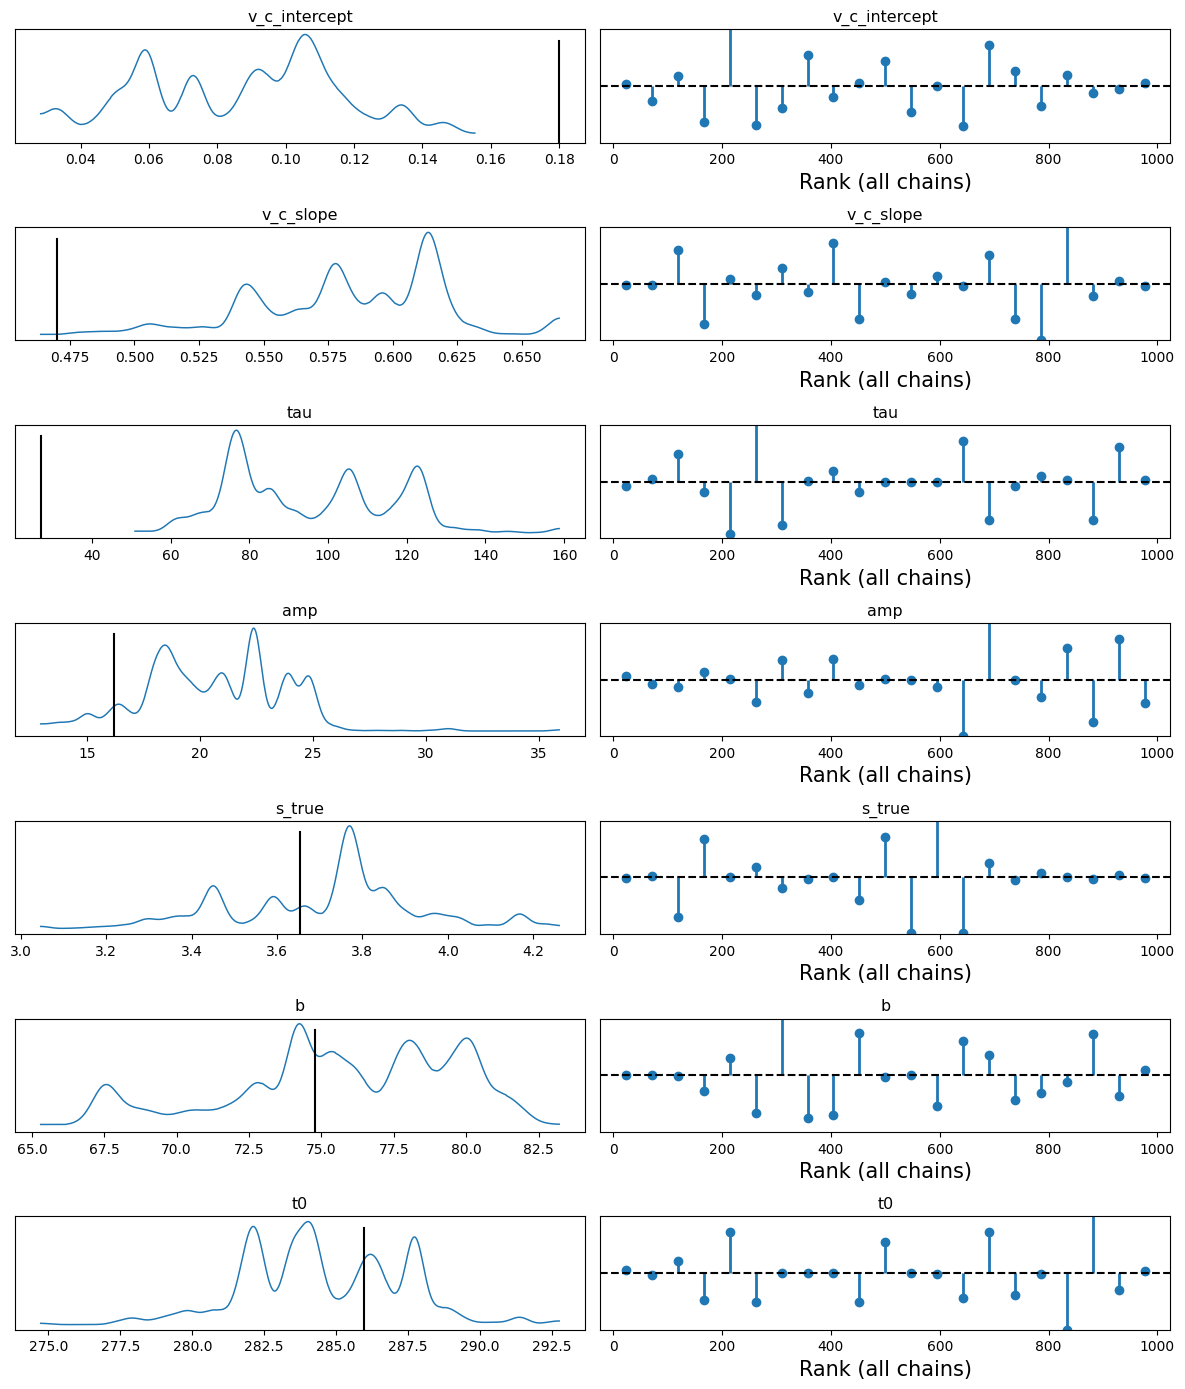

In [42]:
import matplotlib.pyplot as plt
import arviz as az

reference_values = {
    key: val for key, val in zip(param_names, prior_draws)
}

idata = az.from_dict(
    posterior={k: v
               for k, v in zip(param_names, smc_samples.particles.T)},)
ax = az.plot_trace(idata, compact=True, kind="rank_vlines")

for i, p in enumerate(prior_draws):
    ax[i, 0].axvline(p, 0, 0.9, color="k")

plt.tight_layout()

In [43]:
smc_samples.particles.shape

(1000, 7)

(array([  8.,  18.,  43., 110., 126., 204., 142., 296.,  28.,  25.]),
 array([0.46351871, 0.48363674, 0.50375479, 0.52387285, 0.54399085,
        0.56410891, 0.58422697, 0.60434502, 0.62446308, 0.64458108,
        0.66469914]),
 <BarContainer object of 10 artists>)

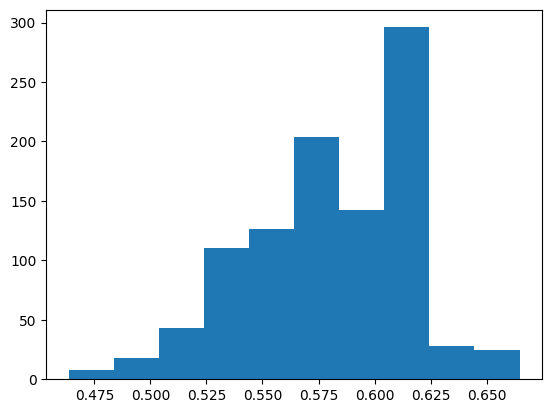

In [44]:
plt.hist(smc_samples.particles[:,1])

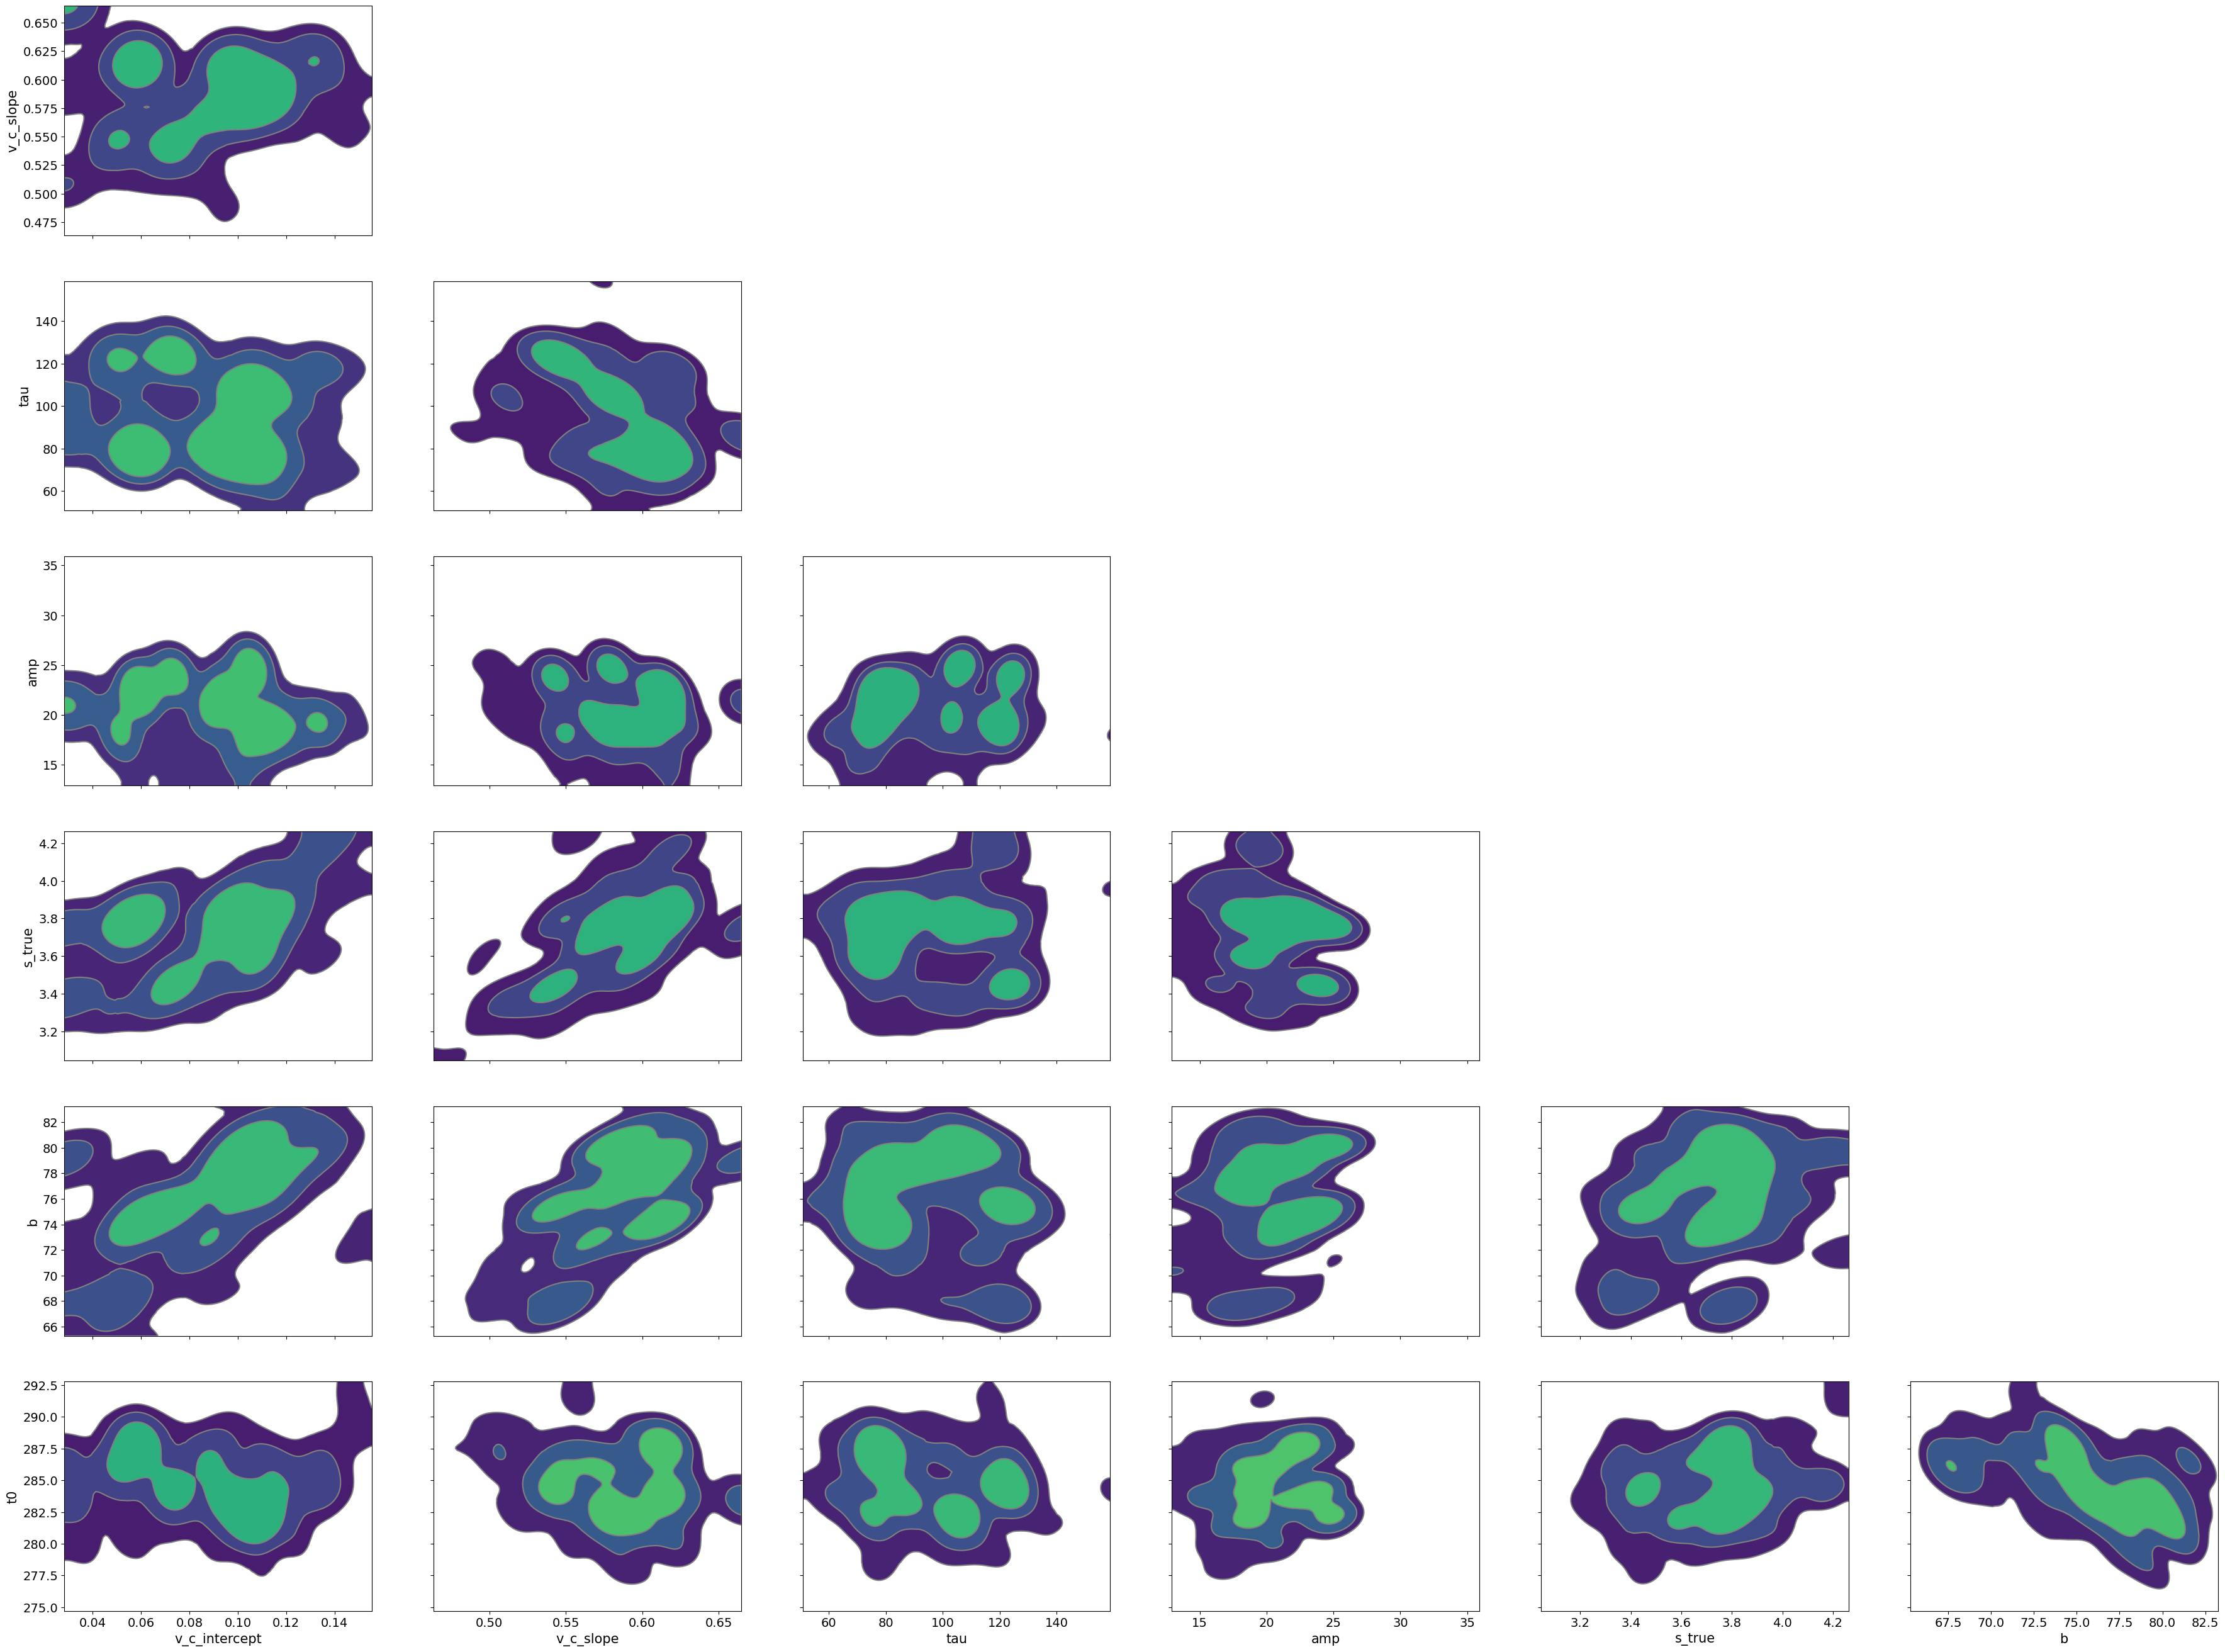

In [46]:
ax = az.plot_pair(idata, kind="kde")